Let's get our data cleaned

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, KFold, cross_validate
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from plotnine import *

In [58]:
# To get just the Medal Counts description part:
medal_desc = pd.read_csv('2025_Problem_C_Data/data_dictionary.csv', skiprows=1, nrows=7, encoding = 'latin1')

# To get the Hosts description:
# You'd count the rows from the top to where "summerOly_hosts.csv" starts
hosts_desc = pd.read_csv('2025_Problem_C_Data/data_dictionary.csv', skiprows=12, nrows=3, encoding = 'latin1')
athletes = pd.read_csv("2025_Problem_C_Data/summerOly_athletes.csv")
hosts = pd.read_csv("2025_Problem_C_Data/summerOly_hosts.csv")
medal_counts = pd.read_csv("2025_Problem_C_Data/summerOly_medal_counts.csv")
# 1. Use encoding='latin1' or 'cp1252' to handle the '' characters
# 2. Use nrows to stop reading before the "Data set of current..." paragraph begins
df_programs = pd.read_csv('2025_Problem_C_Data/summerOly_programs.csv', 
    encoding='latin1', 
    nrows=75  # Adjust this number to the last row of actual data
    )

In [59]:
# 1-3. Build the base historical merges and counts
history = medal_counts.merge(hosts, on="Year", how="left")
athlete_counts = athletes.groupby(['Year', 'Team']).size().reset_index(name='Total_Athletes')
medalist_filter = athletes[athletes['Medal'] != 'No medal']
medalist_counts = medalist_filter.groupby(['Year', 'Team']).size().reset_index(name='Medal_Winning_Athletes')

# 4. Merge these two summaries together into your feature table
athlete_features = athlete_counts.merge(medalist_counts, on=['Year', 'Team'], how='left')

# 5. THE FIX: Calculate Historical Efficiency to prevent data leakage
# A. Sort chronologically to ensure the shift grabs the correct previous year
athlete_features = athlete_features.sort_values(by=['Team', 'Year'])

# B. Calculate the current efficiency temporarily
athlete_features['Current_Efficiency'] = athlete_features['Medal_Winning_Athletes'] / athlete_features['Total_Athletes']

# C. Shift the efficiency down 1 row per team to create the safe, historical metric
athlete_features['Historical_Efficiency'] = athlete_features.groupby('Team')['Current_Efficiency'].shift(1)

# D. Fill first-time appearances (NaNs) with 0, as they have no historical data yet
athlete_features['Historical_Efficiency'] = athlete_features['Historical_Efficiency'].fillna(0)

# E. Drop the leaky columns so they cannot accidentally be fed into the model
athlete_features = athlete_features.drop(columns=['Current_Efficiency', 'Medal_Winning_Athletes'])

I added is_host to make sure that the model would know who the host country is and now we can use that to predict how well the US will do in 2028.

In [60]:
# Assuming 'history' is the table you made by joining medal_counts and hosts
final_training_data = history.merge(athlete_features, left_on=['Year', 'NOC'], right_on = ['Year', 'Team'], how='left')
final_training_data = final_training_data.drop(columns=['Team'])
final_training_data = final_training_data.dropna(subset=['Total_Athletes'])
# Assuming your host column from the merge is named 'Host'
final_training_data['is_Host'] = (final_training_data['NOC'] == final_training_data['Host']).astype(int)
final_training_data.head(15)

,Rank,NOC,Gold,Silver,Bronze,Total,Year,Host,Total_Athletes,Historical_Efficiency,is_Host
0,1,United States,11,7,2,20,1896,"Athens, Greece",27.0,0.000000,0
1,2,Greece,10,18,19,47,1896,"Athens, Greece",140.0,0.000000,0
2,3,Germany,6,5,2,13,1896,"Athens, Greece",93.0,0.000000,0
3,4,France,5,4,2,11,1896,"Athens, Greece",26.0,0.000000,0
4,5,Great Britain,2,3,2,7,1896,"Athens, Greece",23.0,0.000000,0
5,6,Hungary,2,1,3,6,1896,"Athens, Greece",18.0,0.000000,0
6,7,Austria,2,1,2,5,1896,"Athens, Greece",8.0,0.000000,0
7,8,Australia,2,0,0,2,1896,"Athens, Greece",4.0,0.000000,0
8,9,Denmark,1,2,3,6,1896,"Athens, Greece",15.0,0.000000,0
9,10,Switzerland,1,2,0,3,1896,"Athens, Greece",8.0,0.000000,0


Athlete Efficiency takes the number of total medals won divided by the number of athletes sent. The higher the number the better.

We have a bunch of individual athletes who are not apart of a country, so I dropped them.

I want to graph the countries total medals vs which year

## Total medals per year

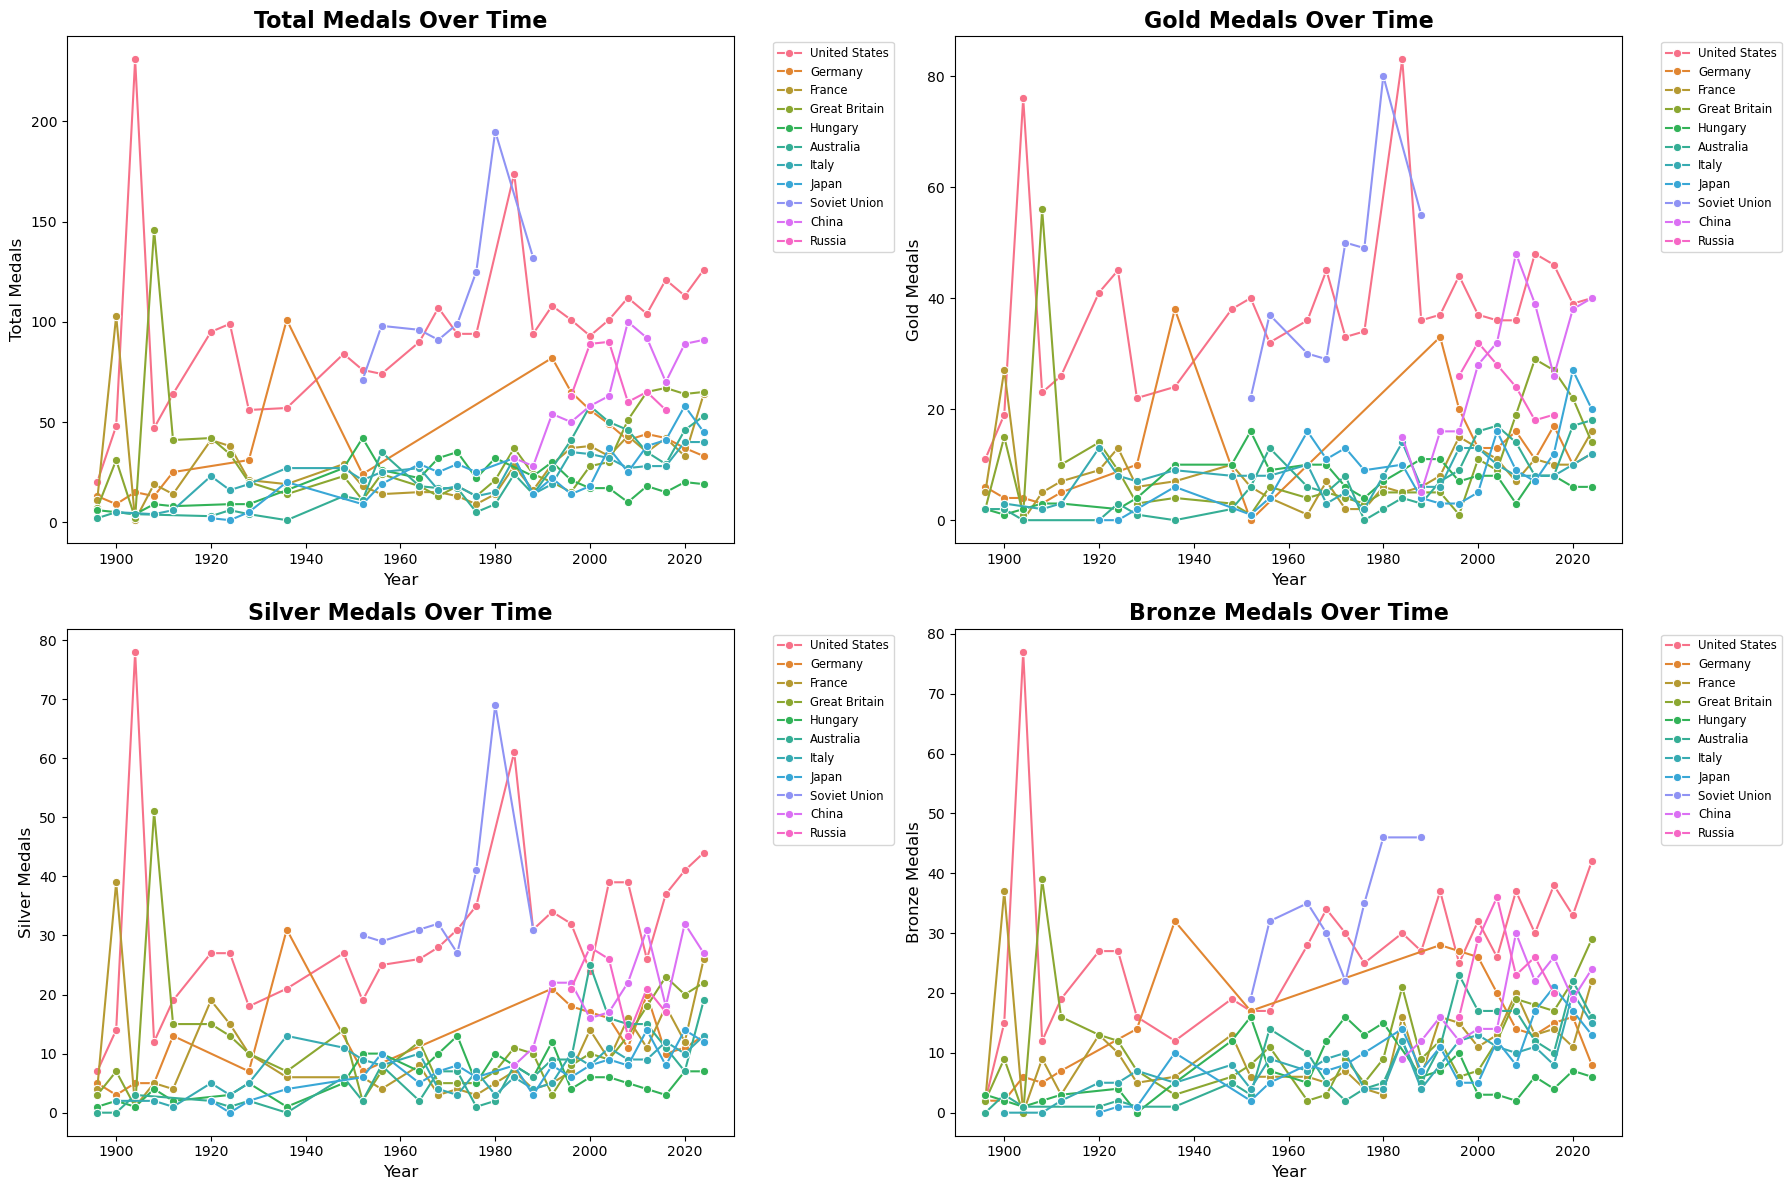

In [61]:
# Identify the Top 10 countries by all-time Total medals
# We use .tolist() so we can easily append another country to it
top_nocs = final_training_data.groupby('NOC')['Total'].sum().nlargest(10).index.tolist()

# Add Russia ('RUS') to the list making it 11 countries 
# (The if-statement ensures we don't add it twice if it naturally made the Top 10)
russia_code = 'Russia' 
if russia_code not in top_nocs:
    top_nocs.append(russia_code)

# Filter the dataframe to just these top countries + Russia
plot_data = final_training_data[final_training_data['NOC'].isin(top_nocs)]

# Set up a 2x2 grid for the 4 graphs
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Define the metrics and their respective graph titles
metrics = ['Total', 'Gold', 'Silver', 'Bronze']
titles = ['Total Medals Over Time', 'Gold Medals Over Time', 
          'Silver Medals Over Time', 'Bronze Medals Over Time']

# Loop through and create each plot
for i, metric in enumerate(metrics):
    sns.lineplot(
        data=plot_data, 
        x='Year', 
        y=metric, 
        hue='NOC', 
        marker='o',
        ax=axes[i]
    )
    
    axes[i].set_title(titles[i], fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Year', fontsize=12)
    axes[i].set_ylabel(f'{metric} Medals', fontsize=12)
    
    # Move the legend outside of the plot area so it doesn't cover the lines
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

We see here that The US, USSR, and China stand out among their peers in total medals. We also see them having the most medals in each medal event individually.

## Training

In [62]:
features = ['Total_Athletes', 'Historical_Efficiency', 'is_Host']
X = final_training_data[features]

# 2. Your target is now a DataFrame with TWO columns
targets = ['Total', 'Gold']
y = final_training_data[targets]

X_train, X_test, y_train_multi, y_test_multi = train_test_split(X, y, train_size = .7, random_state = 4025)

## Linear Pipeline

In [63]:
num = ['Total_Athletes', 'Historical_Efficiency']
cat = ['is_Host']

numeric_transformer = Pipeline(steps=[
    # Fills any blank numeric values with the median of that column
    ('imputer', SimpleImputer(strategy='median')), 
    # Standardizes numbers to have a mean of 0 and variance of 1
    ('scaler', StandardScaler()) 
])
categorical_transformer = Pipeline(steps=[
    # Fills any blank categorical values with the most common category
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # Ensures categories are properly formatted for regression mathematics
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num),
    ('cat', categorical_transformer, cat)
])
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train_multi)
predictions = lr_pipeline.predict(X_test)

# 2. Extract the predictions into separate variables for clarity
# predictions[:, 0] grabs all rows for the first target ('Total')
# predictions[:, 1] grabs all rows for the second target ('Gold')
predicted_total = predictions[:, 0]
predicted_gold = predictions[:, 1]

# 3. Extract the actual values for clarity
actual_total = y_test_multi['Total']
actual_gold = y_test_multi['Gold']

# 4. Calculate the Metrics!
# R2 Score: How much of the variance does the model explain? (Closer to 1.0 is better)
r2_lr_total = r2_score(actual_total, predicted_total)
r2_lr_gold = r2_score(actual_gold, predicted_gold)

# RMSE (Root Mean Squared Error): The average error, penalizing large misses heavily
rmse_lr_total = (root_mean_squared_error(actual_total, predicted_total))
rmse_lr_gold = (root_mean_squared_error(actual_gold, predicted_gold))

# MAE (Mean Absolute Error): The standard average error
mae_lr_total = mean_absolute_error(actual_total, predicted_total)
mae_lr_gold = mean_absolute_error(actual_gold, predicted_gold)

# 5. Print the professional summary
print("===== LINEAR REGRESSION PIPELINE RESULTS =====")
print("\n[TOTAL MEDALS]")
print(f"R² Score: {r2_lr_total:.3f}")
print(f"RMSE:     {rmse_lr_total:.2f} medals")
print(f"MAE:      {mae_lr_total:.2f} medals")

print("\n[GOLD MEDALS]")
print(f"R² Score: {r2_lr_gold:.3f}")
print(f"RMSE:     {rmse_lr_gold:.2f} medals")
print(f"MAE:      {mae_lr_gold:.2f} medals")

===== LINEAR REGRESSION PIPELINE RESULTS =====

[TOTAL MEDALS]
R² Score: 0.620
RMSE:     10.77 medals
MAE:      7.40 medals

[GOLD MEDALS]
R² Score: 0.501
RMSE:     4.59 medals
MAE:      3.16 medals


We see here that the linear model has a high r2 but we see we are off by about 7 total medals and 3 gold medals yet our model occasionally fails with total because of the higher rmse

## KNN Model

In [64]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

# 2. Define the Grid of parameters to search
# - n_neighbors: How many similar countries should it compare to?
# - weights: 'uniform' (all neighbors equal) or 'distance' (closer neighbors count more)
param_grid = {
    'regressor__n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'regressor__weights': ['uniform', 'distance']
}

# 3. Set up GridSearchCV
# cv=5 splits the training data into 5 folds to validate the parameters
grid_search = GridSearchCV(
    estimator=knn_pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2',  # Optimize for the best overall R² score
    n_jobs=-1      # Use all computer processors to speed up the search
)

grid_search.fit(X_train, y_train_multi)

# Extract the absolute best model it found
best_knn = grid_search.best_estimator_
print(f"\n✅ Best Parameters Found: {grid_search.best_params_}")

# 5. Make predictions on your X_test data using the winning model
predictions = best_knn.predict(X_test)

# Extract into separate arrays
predicted_total = predictions[:, 0]
predicted_gold = predictions[:, 1]
actual_total = y_test_multi['Total']
actual_gold = y_test_multi['Gold']

# 6. Calculate Metrics
r2_knn_total = r2_score(actual_total, predicted_total)
rmse_knn_total = (root_mean_squared_error(actual_total, predicted_total))
mae_knn_total = mean_absolute_error(actual_total, predicted_total)

r2_knn_gold = r2_score(actual_gold, predicted_gold)
rmse_knn_gold = (root_mean_squared_error(actual_gold, predicted_gold))
mae_knn_gold = mean_absolute_error(actual_gold, predicted_gold)

# 7. Print the beautiful summary!
print("\n===== KNN REGRESSION (BEST MODEL) RESULTS =====")
print("\n[TOTAL MEDALS]")
print(f"R² Score: {r2_knn_total:.3f}")
print(f"RMSE:     {rmse_knn_total:.2f} medals")
print(f"MAE:      {mae_knn_total:.2f} medals")

print("\n[GOLD MEDALS]")
print(f"R² Score: {r2_knn_gold:.3f}")
print(f"RMSE:     {rmse_knn_gold:.2f} medals")
print(f"MAE:      {mae_knn_gold:.2f} medals")


✅ Best Parameters Found: {'regressor__n_neighbors': 11, 'regressor__weights': 'uniform'}

===== KNN REGRESSION (BEST MODEL) RESULTS =====

[TOTAL MEDALS]
R² Score: 0.717
RMSE:     9.29 medals
MAE:      4.66 medals

[GOLD MEDALS]
R² Score: 0.597
RMSE:     4.12 medals
MAE:      2.13 medals


We see this model do a lot better. We see the total medals getting an r2 of .7 while it misses by 4 on average but we do occasionally fails and the gold misses by 2 medals. I want to make sure our cross_validation is good.

In [65]:
cv_knn_results = cross_validate(
    estimator=best_knn,         # The winning model from your GridSearch
    X=X_train,                 # The training features
    y=y_train_multi,           # The training targets
    cv=5,                  # Your 5-fold cross-validator
    scoring='r2',              # We want the R² score
    return_train_score=True    # CRITICAL: Let's us see if the model is memorizing data
)

# 2. Extract the scores
train_scores = cv_knn_results['train_score']
test_scores = cv_knn_results['test_score']

# 3. Print the fold-by-fold breakdown
print("===== RANDOM FOREST CROSS-VALIDATION CHECK =====")

# 4. Calculate the average and consistency (Standard Deviation)
print(f"\nAverage Validation R²: {test_scores.mean():.3f}")
print(f"Validation R² Spread (Std Dev): ±{test_scores.std():.3f}")

===== RANDOM FOREST CROSS-VALIDATION CHECK =====

Average Validation R²: 0.762
Validation R² Spread (Std Dev): ±0.034


## Random Forrest Pipeline

In [66]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor())
])

param_grid_rf = {
    'rf__max_features': [1, 2, 3],
    'rf__n_estimators' : [50,100,200],
    'rf__max_depth' : [None, 5,10,15]
}
rf_cv = KFold(n_splits = 5, shuffle = True, random_state= 4025)

rf_grid = GridSearchCV(
    estimator = rf_pipeline,
    param_grid= param_grid_rf,
    cv = rf_cv,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train_multi)

# 6. Make Predictions and Evaluate
best_rf = rf_grid.best_estimator_
predictions = best_rf.predict(X_test)

predicted_total = predictions[:, 0]
predicted_gold = predictions[:, 1]
actual_total = y_test_multi['Total']
actual_gold = y_test_multi['Gold']

# 7. Calculate and Print Metrics
r2_rf_total = r2_score(actual_total, predicted_total)
rmse_rf_total = (root_mean_squared_error(actual_total, predicted_total))
mae_rf_total = mean_absolute_error(actual_total, predicted_total)

r2_rf_gold = r2_score(actual_gold, predicted_gold)
rmse_rf_gold = (root_mean_squared_error(actual_gold, predicted_gold))
mae_rf_gold = mean_absolute_error(actual_gold, predicted_gold)

print("\n===== RANDOM FOREST REGRESSOR RESULTS =====")
print("\n[TOTAL MEDALS]")
print(f"R² Score: {r2_rf_total:.3f}")
print(f"RMSE:     {rmse_rf_total:.2f} medals")
print(f"MAE:      {mae_rf_total:.2f} medals")

print("\n[GOLD MEDALS]")
print(f"R² Score: {r2_rf_gold:.3f}")
print(f"RMSE:     {rmse_rf_gold:.2f} medals")
print(f"MAE:      {mae_rf_gold:.2f} medals")




===== RANDOM FOREST REGRESSOR RESULTS =====

[TOTAL MEDALS]
R² Score: 0.737
RMSE:     8.95 medals
MAE:      4.72 medals

[GOLD MEDALS]
R² Score: 0.646
RMSE:     3.86 medals
MAE:      2.05 medals


This model improved a little bit getting us a higher r2 but we are missing by more on average than the KNN for total medals. Our Gold medals had a much better r2. I want to make sure that our r2 is being consistent so I asked Gemini to make a cross_validate on the results we just gained.

In [67]:
cv_rf_results = cross_validate(
    estimator=best_rf,         # The winning model from your GridSearch
    X=X_train,                 # The training features
    y=y_train_multi,           # The training targets
    cv=rf_cv,                  # Your 5-fold cross-validator
    scoring='r2',              # We want the R² score
    return_train_score=True    # CRITICAL: Let's us see if the model is memorizing data
)

# 2. Extract the scores
train_scores = cv_rf_results['train_score']
test_scores = cv_rf_results['test_score']

# 3. Print the fold-by-fold breakdown
print("===== RANDOM FOREST CROSS-VALIDATION CHECK =====")

# 4. Calculate the average and consistency (Standard Deviation)
print(f"\nAverage Validation R²: {test_scores.mean():.3f}")
print(f"Validation R² Spread (Std Dev): ±{test_scores.std():.3f}")

===== RANDOM FOREST CROSS-VALIDATION CHECK =====

Average Validation R²: 0.761
Validation R² Spread (Std Dev): ±0.068


All good!!

## HistGrad

In [71]:
num_transformer_no = Pipeline([
    ('scaler', StandardScaler())
])
cat_transformer_no = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessr_no_impute = ColumnTransformer([
    ('num', num_transformer_no, num),
    ('cat', cat_transformer_no, cat)
])
pipeline_impute = Pipeline([
    ('preprocessor', preprocessor),
    ('multi_regressor', MultiOutputRegressor(HistGradientBoostingRegressor(random_state=4025)))
])
pipeline_noimpute = Pipeline([
    ('preprocessor', preprocessr_no_impute),
    ('multi_regressor', MultiOutputRegressor(HistGradientBoostingRegressor(random_state=4025)))
])
models_to_test = {
    "HistGradient (WITH Imputer)": pipeline_impute,
    "HistGradient (NO Imputer)": pipeline_noimpute
}
param_grid = {
    'multi_regressor__estimator__learning_rate': [0.05, 0.1, 0.2],
    'multi_regressor__estimator__max_iter': [100, 200, 300],
    'multi_regressor__estimator__max_depth': [None, 5, 10]
}
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=4025)
results = {}

for name, pipeline in models_to_test.items():
    print(f"Training {name}...")
    
    # Run GridSearch
    grid = GridSearchCV(pipeline, param_grid, cv=cv_strategy, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train_multi)
    
    # Predict
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    
    # Calculate TOTAL Medals Metrics (Column 0)
    r2_tot = r2_score(y_test_multi['Total'], preds[:, 0])
    rmse_tot = root_mean_squared_error(y_test_multi['Total'], preds[:, 0])
    mae_tot = mean_absolute_error(y_test_multi['Total'], preds[:, 0])

    # Calculate GOLD Medals Metrics (Column 1)
    r2_gld = r2_score(y_test_multi['Gold'], preds[:, 1])
    rmse_gld = root_mean_squared_error(y_test_multi['Gold'], preds[:, 1])
    mae_gld = mean_absolute_error(y_test_multi['Gold'], preds[:, 1])
    
    # Save ALL results
    results[name] = {
        'Total_R2': r2_tot, 
        'Total_RMSE': rmse_tot, 
        'Total_MAE': mae_tot, 
        'Gold_R2': r2_gld,
        'Gold_RMSE': rmse_gld,
        'Gold_MAE': mae_gld,
        'BestParams': grid.best_params_
    }

print("\n===== HIST-GRADIENT SHOWDOWN =====")
for name, metrics in results.items():
    print(f"\n🥇 {name}:")
    print(f"  [TOTAL] R²: {metrics['Total_R2']:.3f} | RMSE: {metrics['Total_RMSE']:.2f} | MAE: {metrics['Total_MAE']:.2f}")
    print(f"  [GOLD]  R²: {metrics['Gold_R2']:.3f} | RMSE: {metrics['Gold_RMSE']:.2f} | MAE: {metrics['Gold_MAE']:.2f}")

print("\n🏆 Winner for Total R²: ", max(results, key=lambda k: results[k]['Total_R2']))
print("🏆 Winner for Gold R²:  ", max(results, key=lambda k: results[k]['Gold_R2']))

Training HistGradient (WITH Imputer)...
Training HistGradient (NO Imputer)...

===== HIST-GRADIENT SHOWDOWN =====

🥇 HistGradient (WITH Imputer):
  [TOTAL] R²: 0.764 | RMSE: 8.48 | MAE: 4.56
  [GOLD]  R²: 0.672 | RMSE: 3.72 | MAE: 2.03

🥇 HistGradient (NO Imputer):
  [TOTAL] R²: 0.764 | RMSE: 8.48 | MAE: 4.56
  [GOLD]  R²: 0.672 | RMSE: 3.72 | MAE: 2.03

🏆 Winner for Total R²:  HistGradient (WITH Imputer)
🏆 Winner for Gold R²:   HistGradient (WITH Imputer)


Now lets compare the models

In [75]:
hist_name = "HistGradient (WITH Imputer)"
hist_r2_tot = results[hist_name]['Total_R2']
hist_rmse_tot = results[hist_name]['Total_RMSE']
hist_mae_tot = results[hist_name]['Total_MAE']
hist_r2_gold = results[hist_name]['Gold_R2']
hist_rmse_gold = results[hist_name]['Gold_RMSE']
hist_mae_gold = results[hist_name]['Gold_MAE']

# 2. Build the Master Dictionary
summary_data = {
    "Model": [
        "Linear Regression", 
        "KNN Regressor", 
        "Random Forest", 
        "HistGradient Boosting"
    ],
    
    # --- TOTAL MEDALS METRICS ---
    "Total_R²": [r2_lr_total, r2_knn_total, r2_rf_total, hist_r2_tot],
    "Total_RMSE": [rmse_lr_total, rmse_knn_total, rmse_rf_total, hist_rmse_tot],
    "Total_MAE": [mae_lr_total, mae_knn_total, mae_rf_total, hist_mae_tot],
    
    # --- GOLD MEDALS METRICS ---
    "Gold_R²": [r2_lr_gold, r2_knn_gold, r2_rf_gold, hist_r2_gold],
    "Gold_RMSE": [rmse_lr_gold, rmse_knn_gold, rmse_rf_gold, hist_rmse_gold],
    "Gold_MAE": [mae_lr_gold, mae_knn_gold, mae_rf_gold, hist_mae_gold]
}

# 3. Convert to a DataFrame
scoreboard_df = pd.DataFrame(summary_data)

# 4. FIX: Use .apply() instead of .applymap() or .map() 
# .apply() is the safest and most robust way to round entire columns in modern Pandas
numeric_cols = ["Total_R²", "Total_RMSE", "Total_MAE"]
scoreboard_df[numeric_cols] = scoreboard_df[numeric_cols].apply(lambda x: round(x, 3))

# 5. Display the final table!
print("\n" + "="*70)
print("🏆 OLYMPIC MODEL SHOWDOWN - FINAL SCOREBOARD 🏆")
print("="*70)
print(scoreboard_df.to_string(index=False))


🏆 OLYMPIC MODEL SHOWDOWN - FINAL SCOREBOARD 🏆
                Model  Total_R²  Total_RMSE  Total_MAE  Gold_R²  Gold_RMSE  Gold_MAE
    Linear Regression     0.620      10.772      7.400 0.500610   4.585464  3.164341
        KNN Regressor     0.717       9.293      4.659 0.596629   4.121128  2.125142
        Random Forest     0.737       8.949      4.720 0.646196   3.859625  2.052962
HistGradient Boosting     0.764       8.484      4.558 0.672076   3.715781  2.032755


We see that HistGradient Boosting gives us the best R2 with the lowest on average missing for total medals and gold medals. We will now predict the 2028!

## 2028

In [80]:
test_data = final_training_data[final_training_data['Year'] == 2024].copy()
y_test_multi = test_data[['Total', 'Gold']]
# We need to make a copy of our data
data_2028 = test_data[['NOC', 'Total_Athletes']].copy()

# We add the historical efficiency into this dataset as well
data_2028['Historical_Efficiency'] = y_test_multi['Total'] / data_2028['Total_Athletes']

# Fill in any weird Nan
data_2028['Historical_Efficiency'] = data_2028['Historical_Efficiency'].replace([np.inf, -np.inf], 0).fillna(0)

# USA gets the advantage
data_2028['is_Host'] = (data_2028['NOC'] == 'USA').astype(int)

# We want our 3 features
X_2028 = data_2028[['Total_Athletes', 'Historical_Efficiency', 'is_Host']]

pipeline_impute.fit(X_train, y_train_multi)
predictions_2028 = pipeline_impute.predict(X_2028)

# Extract Total and Gold, and round them to whole numbers
data_2028['Predicted_Total'] = np.round(predictions_2028[:, 0]).astype(int)
data_2028['Predicted_Gold'] = np.round(predictions_2028[:, 1]).astype(int)

# Sort by Most Gold Medals (Standard Olympic Ranking), then Most Total Medals
leaderboard_2028 = data_2028.sort_values(by=['Predicted_Gold', 'Predicted_Total'], ascending=[False, False])

# Print the Results!
print("\n" + "="*50)
print("🇺🇸 OFFICIAL 2028 LOS ANGELES MEDAL PROJECTIONS 🇺🇸")
print("="*50)
print(leaderboard_2028[['NOC', 'Predicted_Gold', 'Predicted_Total']].head(20).to_string(index=False))



🇺🇸 OFFICIAL 2028 LOS ANGELES MEDAL PROJECTIONS 🇺🇸
          NOC  Predicted_Gold  Predicted_Total
United States              26               65
    Australia              25               61
       France              25               61
      Germany              25               61
        China              12               35
  Netherlands              10               35
       Brazil               8               23
        Spain               6               25
        Japan               6               22
        Italy               6               22
Great Britain               5               27
       Canada               5               27
       Poland               5               11
   Kazakhstan               3                9
      Ireland               3                6
      Hungary               2               13
  New Zealand               2               12
      Ukraine               2               12
      Belgium               2                9
   Uzbeki

Now lets graph them to get a closer look

In [84]:
sns.set_theme(style="whitegrid")

# 1. Prepare data for plotting (Top 15 Countries)
plot_data = leaderboard_2028.head(15)

# --- CHART 1: TOTAL MEDALS ---
plt.tight_layout()
ax1 = sns.barplot(
    x='Predicted_Total', 
    y='NOC', 
    data=plot_data.sort_values('Predicted_Total', ascending=False),
    palette='viridis'
)
plt.title('Top 15 Projected Nations: Total Medals (LA 2028)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Total Medals')
plt.ylabel('Country (NOC)')

# Add labels to the ends of the bars
for i in ax1.containers:
    ax1.bar_label(i, padding=3)

plt.savefig('2028_total_medals_projection.png', bbox_inches='tight', dpi=300)
plt.close() # Close to start a fresh plot

# --- CHART 2: GOLD MEDALS ---
plt.tight_layout()
ax2 = sns.barplot(
    x='Predicted_Gold', 
    y='NOC', 
    data=plot_data.sort_values('Predicted_Gold', ascending=False),
    palette='magma'
)
plt.title('Top 15 Projected Nations: Gold Medals (LA 2028)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Gold Medals')
plt.ylabel('Country (NOC)')

# Add labels to the ends of the bars
for i in ax2.containers:
    ax2.bar_label(i, padding=3)

plt.savefig('2028_gold_medals_projection.png', bbox_inches='tight', dpi=300)
plt.close()

print("Graphs have been saved as '2028_total_medals_projection.png' and '2028_gold_medals_projection.png'")

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_21176\1908376634.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

C:\Users\cjfoo\AppData\Local\Temp\ipykernel_21176\1908376634.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Graphs have been saved as '2028_total_medals_projection.png' and '2028_gold_medals_projection.png'
